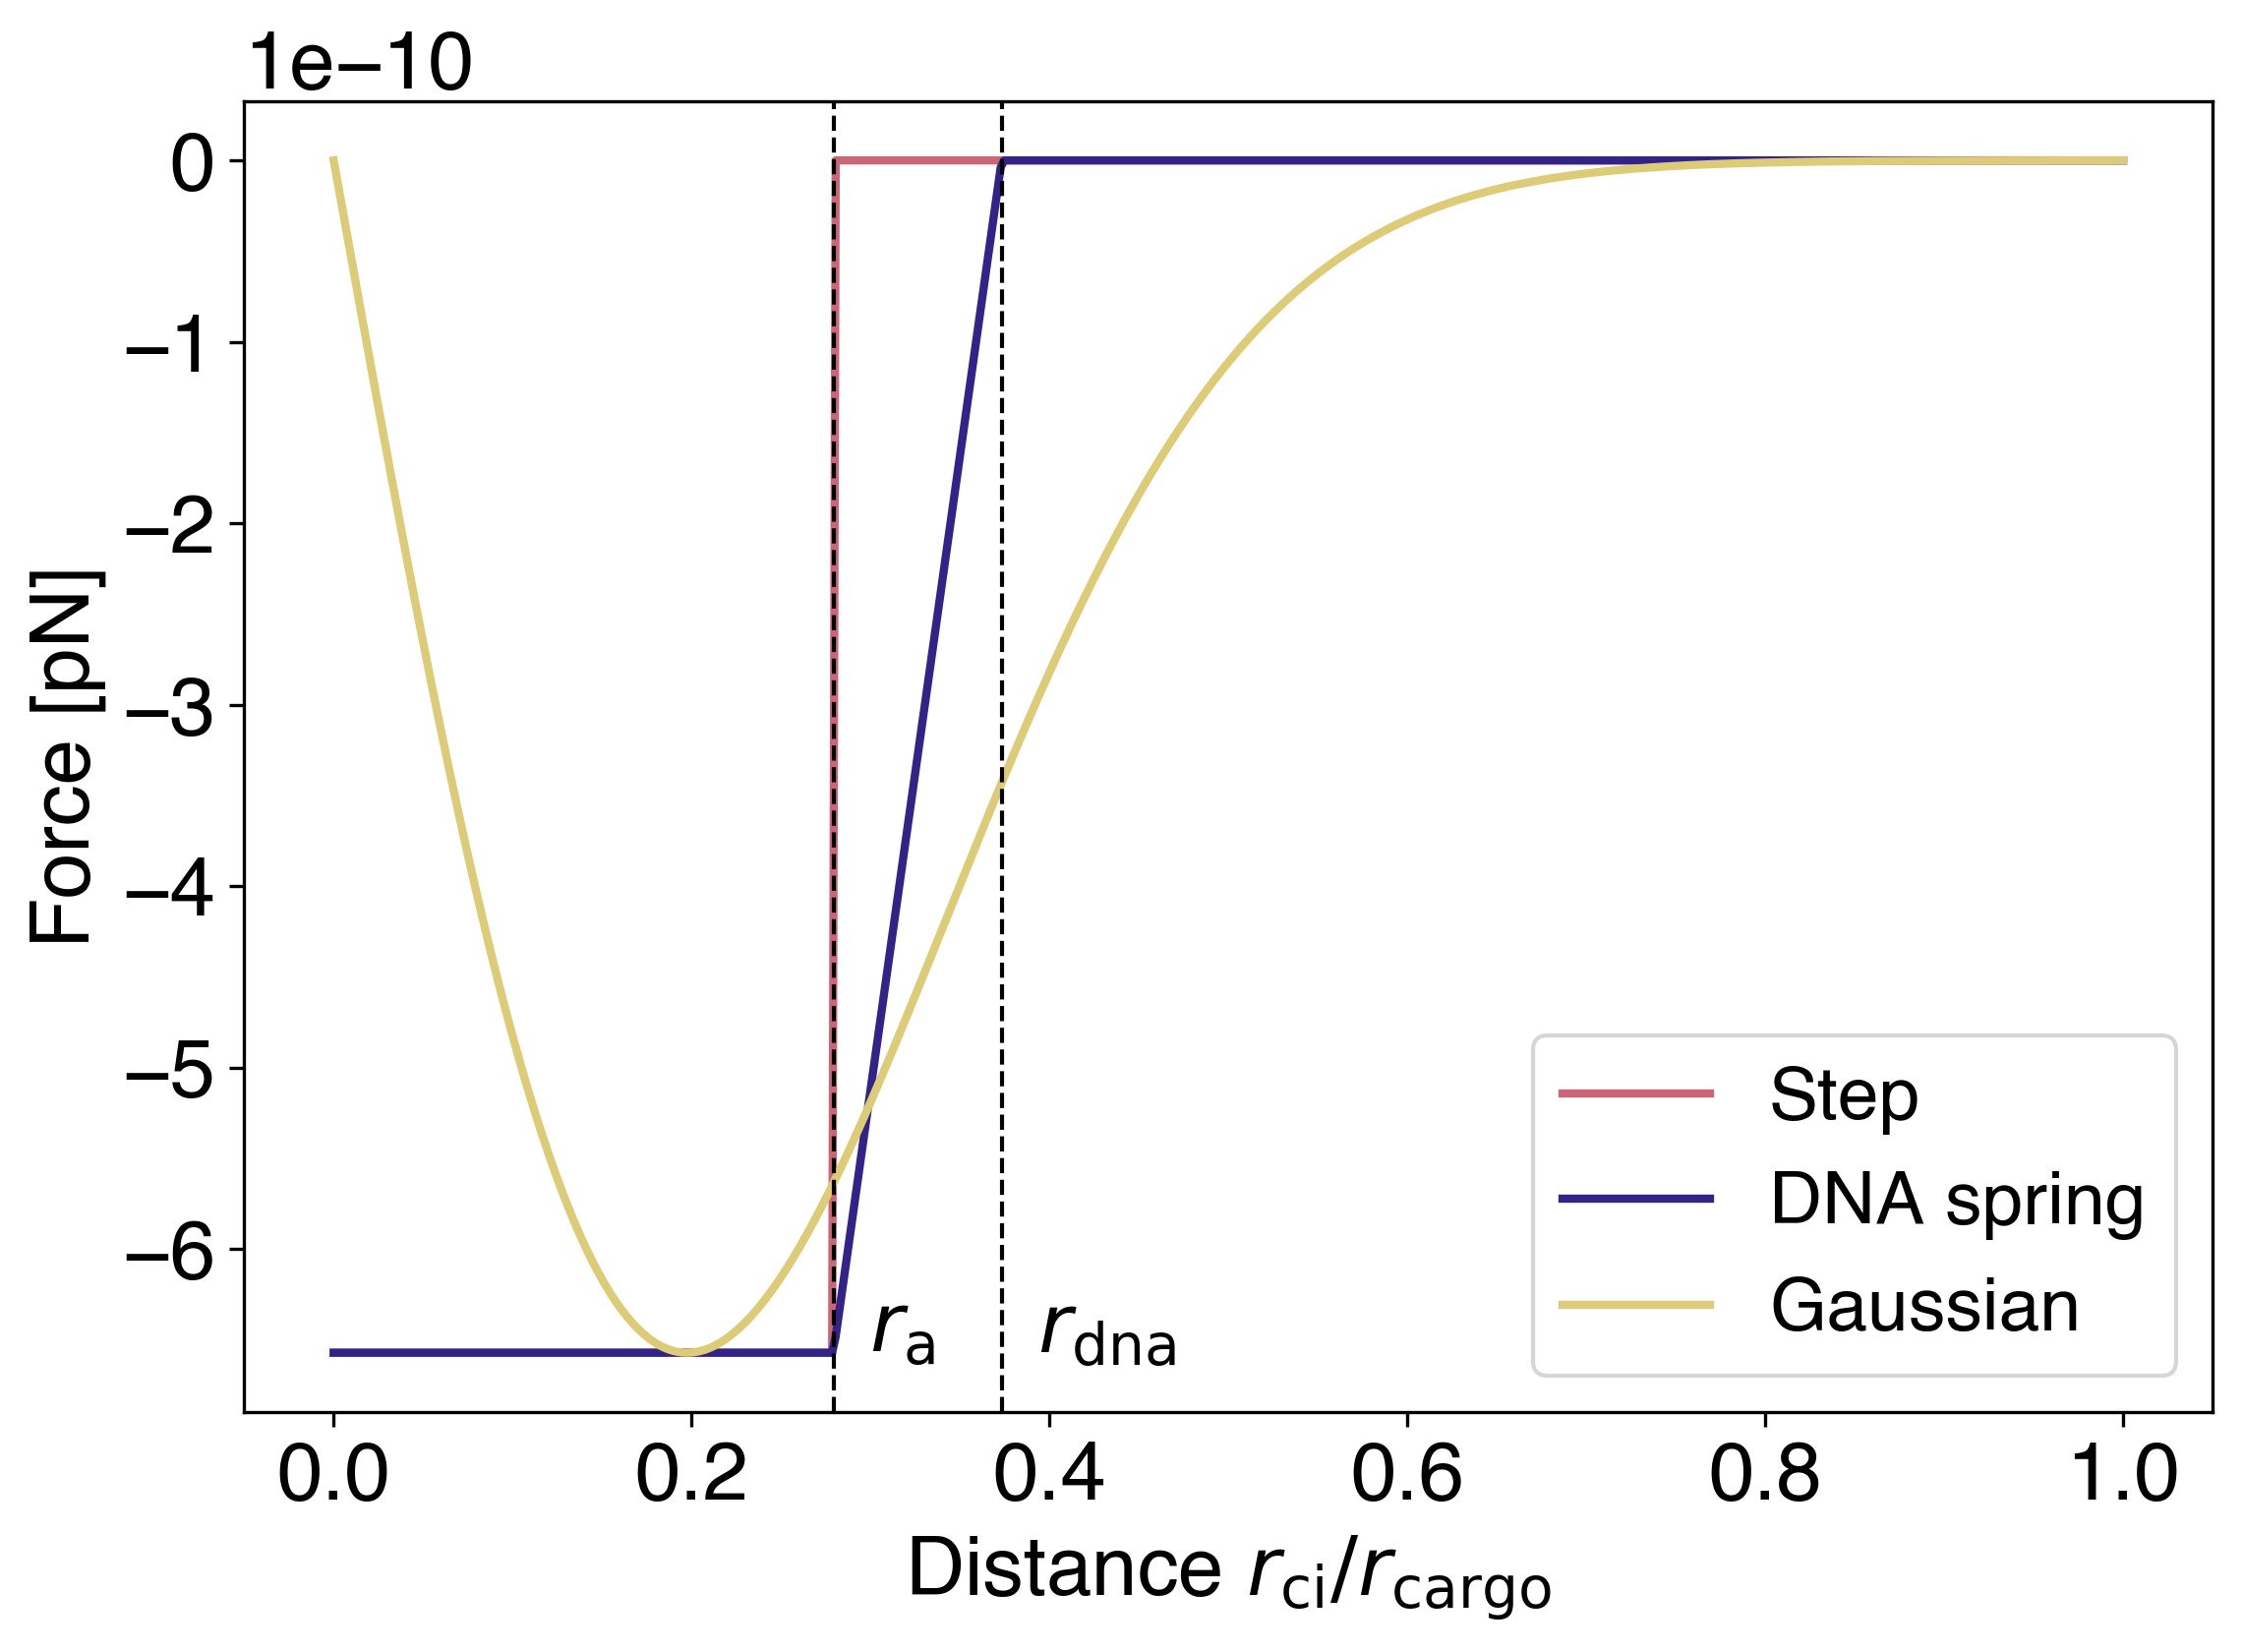

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use('styles/my_style.mplstyle')

def dna_force_gaussian(epsilon, r, r_a):
    return -2 * epsilon * r * np.exp(-(r**2)/(r_a**2)) / (r_a**2)

def dna_force(f, r, r_a):
    if r < r_a:
        return -f
    else:
        return 0.0

def dna_force_spring(f, r, r_a, r_dna):
    if r < r_a:
        return -f
    elif r_a <= r < r_dna:
        return -f * (r_dna - r) / (r_dna - r_a)
    else:
        return 0.0

r = 0.59
d = 0.025
l = 0.010
r_a = np.sqrt(2 * r * d / (1 + d/r)**2)/r
r_dna = np.sqrt((d+2*l)*(2*r+2*l))/(r*(1+(2*l+d/2)/r))

f = 6.57e-10
epsilon = np.sqrt(np.exp(1)/2) * r_a * f 

distances = np.linspace(0, 1.0, 500)

fig, ax = plt.subplots()

ax.plot(distances, [dna_force(f, r, r_a) for r in distances], label='Step')
ax.plot(distances, [dna_force_spring(f, r, r_a, r_dna) for r in distances], label='DNA spring')
ax.plot(distances, [dna_force_gaussian(epsilon, r, r_a) for r in distances], label='Gaussian')

ax.axvline(r_a, color='black', lw=1, ls='--')
ax.axvline(r_dna, color='black', lw=1, ls='--')

ax.text(r_a + 0.02, -f, '$r_\mathrm{a}$')
ax.text(r_dna + 0.02, -f, '$r_\mathrm{dna}$')

ax.set_xlabel('Distance $r_\mathrm{ci}/r_\mathrm{cargo}$')
ax.set_ylabel('Force [pN]')
ax.legend()
plt.show()